<p style="text-align:center">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" />
</p>

# Final Project: Building an Image Classifier with Transfer Learning
## (TensorFlow / Keras Version)

**Estimated time needed: ~60 minutes**

## Overview
This notebook replicates the PyTorch transfer-learning assignment using TensorFlow/Keras.
All 25 exercises cover the same concepts; the table below maps every key construct.

| Concept | PyTorch | TensorFlow/Keras |
|---|---|---|
| Pretrained backbone | `resnet18` (512-d FC) | `ResNet50` (2048-d, no built-in ResNet18 in TF) |
| Dataset loader | `ImageFolder` + `DataLoader` | `image_dataset_from_directory` |
| Normalisation | `transforms.Normalize(mean, std)` | `resnet50.preprocess_input` |
| Training loop | Manual epoch loop | `model.fit()` |
| Loss | `nn.CrossEntropyLoss` | `SparseCategoricalCrossentropy(from_logits=True)` |
| Optimiser | `torch.optim.SGD` | `tf.keras.optimizers.SGD` |
| CyclicLR | `torch.optim.lr_scheduler.CyclicLR` | Custom `CyclicLRCallback` |
| Best-weight tracking | `copy.deepcopy(model.state_dict())` | Custom `BestWeightsTracker` callback |
| Save / load | `torch.save` / `torch.load` | `model.save_weights` / `model.load_weights` |


# About the Dataset

* **stop** – images containing stop signs
* **not_stop** – images without stop signs

Images are JPG, resized to **224×224** for the model.  Split: **90% training / 10% validation**.


## Install and Import Libraries

In [1]:
# TensorFlow is pre-installed on Colab / Skills Network.
# Uncomment only if needed:
# !pip install tensorflow --quiet
!pip install numpy pandas matplotlib tqdm pillow requests --quiet


### OS / Cloud libraries

In [2]:
import os
import shutil
import json
import zipfile
import io
import requests
import random
import time
from datetime import datetime


### Data / Visualisation libraries

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


### TensorFlow / Keras libraries

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import SparseCategoricalCrossentropy

tf.random.set_seed(0)
print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.20.0


## Helper Functions

### `plot_stuff` — Training loss and validation accuracy
Plots training loss (red, left axis) and validation accuracy (blue, right axis) over epochs.
Identical to the PyTorch version.


In [7]:
def plot_stuff(COST, ACC):
    """
    Plots training cost (loss) and validation accuracy on the same figure using two y-axes.

    Parameters:
    COST (list): Average training loss per epoch.
    ACC  (list): Validation accuracy per epoch (0-1 scale).
    """
    fig, ax1 = plt.subplots()

    color = "tab:red"
    ax1.plot(COST, color=color)
    ax1.set_xlabel("Epoch", color=color)
    ax1.set_ylabel("Total Loss", color=color)
    ax1.tick_params(axis="y", labelcolor=color)

    ax2 = ax1.twinx()
    color = "tab:blue"
    ax2.set_ylabel("Accuracy", color=color)
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis="y", labelcolor=color)

    fig.tight_layout()
    plt.show()


### `imshow_` — Display a preprocessed image tensor

In TF, images have shape `[H, W, C]` (height-first) unlike PyTorch's `[C, H, W]`,
so no permute is needed. We undo `preprocess_input`'s mean subtraction for display.


In [8]:
def imshow_(inp, title=None):
    """
    Displays a TF image array of shape (H, W, C) after reversing ResNet50 preprocess_input.

    preprocess_input converts RGB to BGR and subtracts channel-wise ImageNet means.
    We approximate the inverse: add BGR means back, flip to RGB, scale to [0,1].

    Parameters:
    - inp   : numpy array or EagerTensor of shape (H, W, C).
    - title : optional title string.
    """
    inp = inp.numpy() if hasattr(inp, "numpy") else np.array(inp)
    print("Image shape:", inp.shape)

    # preprocess_input: converts RGB->BGR and subtracts these means
    bgr_means = np.array([103.939, 116.779, 123.68])
    inp = inp[..., ::-1]               # BGR -> RGB
    inp = (inp + bgr_means) / 255.0   # undo mean subtraction; scale to [0,1]
    inp = np.clip(inp, 0, 1)

    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)
    plt.show()


### Device / GPU check

In [9]:
gpus = tf.config.list_physical_devices("GPU")
print("GPUs available:", gpus if gpus else "None — running on CPU")


GPUs available: None — running on CPU


## Image Processing and Load Data for Dataset Preparation

We download the same ZIP file and apply the same JSON-guided 90/10 split as the PyTorch version.


### Download and extract the dataset

In [10]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ExisQFol3hUHktTjm6a51w/final-project-stop-signs-1-2025-04-25-t-06-47-41-058-z.zip"

response = requests.get(url)
if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall("not_stopandstop")
    print("Download and extraction complete.")
else:
    print("Failed to download file:", response.status_code)
    


Download and extraction complete.


### Set paths and load annotations

In [11]:
source_dir       = "not_stopandstop/final-project-stop-signs-1-2025-04-25-t-06-47-41-058-z"
annotations_file = os.path.join(source_dir, "_annotations.json")

with open(annotations_file, "r") as f:
    annotations = json.load(f)


### 90/10 train/val split (identical logic to PyTorch version)

In [12]:
train_ratio = 0.9
output_dir  = "dataset"

label_to_images = {}
for filename, entry in annotations["annotations"].items():
    label = entry[0]["label"]
    label_to_images.setdefault(label, []).append(filename)

for label, image_list in label_to_images.items():
    random.shuffle(image_list)
    train_cutoff = int(len(image_list) * train_ratio)
    train_images = image_list[:train_cutoff]
    val_images   = image_list[train_cutoff:]

    for split, split_images in zip(["train", "val"], [train_images, val_images]):
        out_path = os.path.join(output_dir, split, label)
        os.makedirs(out_path, exist_ok=True)
        for img_name in split_images:
            src = os.path.join(source_dir, img_name)
            dst = os.path.join(out_path, img_name)
            shutil.copy2(src, dst)

print("Train/Val split complete.")


Train/Val split complete.


## Exercise 1: Apply Image Transformations

In TensorFlow we define a **preprocessing function** instead of a `transforms.Compose` pipeline.

| PyTorch | TensorFlow equivalent |
|---|---|
| `transforms.Resize((224, 224))` | `tf.image.resize(image, (224, 224))` |
| `transforms.ToTensor()` | Already a tensor from `image_dataset_from_directory` |
| `transforms.Normalize(mean, std)` | `preprocess_input(image)` from `resnet50` |

`preprocess_input` applies the **exact same channel normalisation** that ResNet50
was trained with on ImageNet (BGR mean subtraction).


In [13]:
IMG_SIZE = (224, 224)   # Same as PyTorch: Resize((224, 224))

def preprocess_image(image, label):
    """
    Applies the same preprocessing as the PyTorch pipeline:
        transforms.Compose([Resize(224,224), ToTensor(), Normalize(mean, std)])

    tf.image.resize  -> Resize to 224x224
    preprocess_input -> ResNet50 normalisation (subtracts ImageNet BGR channel means)
    """
    image = tf.image.resize(image, IMG_SIZE)  # Resize to 224x224
    image = preprocess_input(image)           # ResNet50 normalisation
    return image, label

print("Preprocessing function defined.")


Preprocessing function defined.


## Exercise 2: Load Datasets with Transformations

`image_dataset_from_directory` is the TF equivalent of PyTorch's `ImageFolder`.
Class names are inferred **alphabetically** from subfolder names — same as `ImageFolder.classes`.


In [14]:
BATCH_SIZE = 32    # Defined here; confirmed in Exercise 5

AUTOTUNE = tf.data.AUTOTUNE

# --- Training dataset (shuffle=True, same as DataLoader shuffle=True) ---
train_dataset_raw = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=0
)

# --- Validation dataset (no shuffle, batch_size=1 mirrors PyTorch validation_loader) ---
val_dataset_raw = tf.keras.utils.image_dataset_from_directory(
    "dataset/val",
    image_size=IMG_SIZE,
    batch_size=1,
    shuffle=False
)


Found 197 files belonging to 2 classes.
Found 66 files belonging to 2 classes.


In [15]:

# Class list inferred alphabetically: not_stop=0, stop=1
class_names = train_dataset_raw.class_names
print("Classes:", class_names)

n_val = sum(1 for _ in val_dataset_raw.unbatch())
print("Validation images:", n_val)

# Apply preprocessing and cache/prefetch for speed
train_dataset = (train_dataset_raw
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .prefetch(AUTOTUNE))
val_dataset   = (val_dataset_raw
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .prefetch(AUTOTUNE))


Classes: ['not_stop', 'stop']
Validation images: 66


## Exercise 3: Visualise Samples from the Validation Set

Mirrors the PyTorch loop that displayed the first 3 images from `val_dataset`.


Image shape: (224, 224, 3)


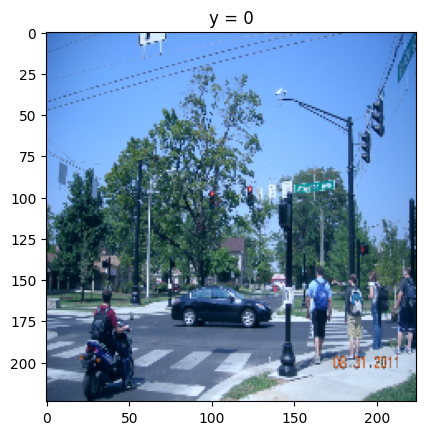

Image shape: (224, 224, 3)


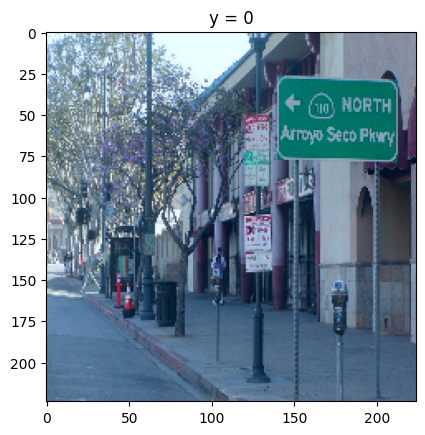

Image shape: (224, 224, 3)


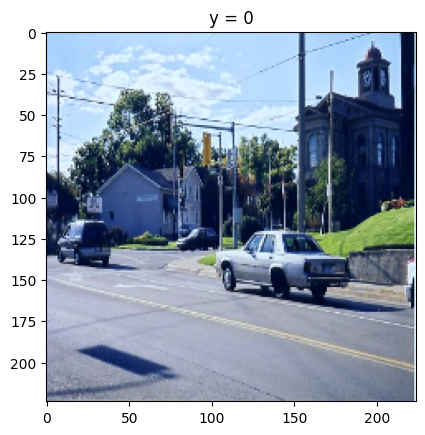

Image shape: (224, 224, 3)


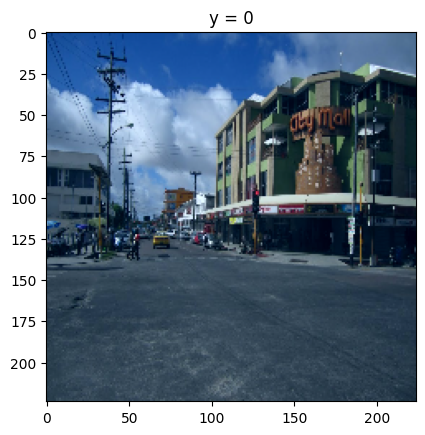

In [23]:
i = 0
for image_batch, label_batch in val_dataset.take(4):
    for img, lbl in zip(image_batch, label_batch):
        imshow_(img, title=f"y = {lbl.numpy()}")
        i += 1
        if i == 3:
            break


## Exercise 4: Reflect on Your Dataset and Transformations

**1. Why is normalisation important when using pretrained models?**

ResNet50 was trained on ImageNet using `preprocess_input`, which subtracts channel-wise
BGR means from every pixel. Feeding raw [0, 255] pixels violates the distribution the
weights were calibrated for, degrading feature quality and slowing convergence.
Using the same normalisation aligns the input statistics with what the backbone expects.

**2. What benefits does resizing images to (224, 224) provide?**

ResNet50's architecture is designed around 224×224 input: its strided convolutions and
pooling layers produce a 7×7 feature map at that size. A fixed size also lets us stack
images into uniform-shape batches. Using the training-time size gives the best spatial
alignment between learned filters and incoming features.

**3. What would happen if input sizes varied?**

`image_dataset_from_directory` would raise a batch-shape mismatch error.
Even if batching were bypassed, the `GlobalAveragePooling2D` output size would change
for different spatial inputs, breaking the Dense classifier head (which expects a fixed
2048-dimensional vector).


## Hyperparameters

## Exercise 5: Epochs and Batch Size

Same reasoning as the PyTorch version: 10 epochs is enough for transfer learning
on a small dataset; batch size 32 balances gradient stability and memory.


In [24]:
n_epochs   = 10   # One full pass through training data per epoch
batch_size = 32   # Stable gradients, reasonable GPU/CPU memory

# Rebuild datasets with confirmed batch size
train_dataset = (
    tf.keras.utils.image_dataset_from_directory(
        "dataset/train", image_size=IMG_SIZE,
        batch_size=batch_size, shuffle=True, seed=0
    )
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_dataset = (
    tf.keras.utils.image_dataset_from_directory(
        "dataset/val", image_size=IMG_SIZE,
        batch_size=1, shuffle=False
    )
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
print(f"n_epochs={n_epochs}, batch_size={batch_size}")


Found 197 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
n_epochs=10, batch_size=32


## Exercise 6: Configure Learning Rate and Momentum

Same values as the PyTorch version — the SGD API is identical.


In [25]:
learning_rate = 0.001   # Small positive step size for stable convergence
momentum      = 0.9     # Accelerates gradients in consistent directions


## Exercise 7: Learning Rate Scheduler — Understanding and Setup

TF/Keras has no built-in CyclicLR, so we implement a **custom Callback** that exactly
replicates `torch.optim.lr_scheduler.CyclicLR(mode="triangular2", step_size_up=5)`.

**triangular2 formula:**
```
cycle    = floor(1 + epoch / (2 * step_size_up))
x        = |epoch / step_size_up - 2*cycle + 1|
scale    = 1 / 2^(cycle - 1)          # amplitude halves each full cycle
lr       = base_lr + (max_lr - base_lr) * max(0, 1-x) * scale
```


In [26]:
use_lr_scheduler = True    # True = CyclicLR; False = constant LR
base_lr          = 0.001   # Minimum learning rate
max_lr           = 0.01    # Maximum learning rate


## Exercise 8: Analyse Training Configuration

**1. What is the purpose of choosing a specific number of epochs?**

Epochs control how many complete passes the model makes over training data.
Too few → underfitting (not enough learning). Too many → overfitting (memorising training images).
Tracking validation accuracy and restoring the best weights mitigates overfitting risk.

**2. Why is it important to choose an appropriate batch size?**

Very small batches produce noisy gradients (high variance, slow convergence).
Very large batches reduce randomness, can lead to sharp minima that generalise poorly,
and require more memory. Batch size 32 is a well-tested default for image classification.

**3. How does a learning rate scheduler help model training?**

A fixed LR may be too large early (overshooting minima) or too small later (very slow convergence).
CyclicLR oscillates between `base_lr` and `max_lr`, helping the optimiser escape flat regions
and saddle points. The `triangular2` decay ensures the amplitude shrinks each cycle,
guiding the model toward a stable, good solution.


## Load Model and Train

## Exercise 9: Load a Pretrained Model

`models.resnet18(pretrained=True)` in PyTorch → `ResNet50(weights="imagenet", include_top=False)` in TF.

**Why ResNet50, not ResNet18?**
TF/Keras's `keras.applications` does not ship ResNet18.
ResNet50 is the standard, widely-used substitute — it follows the same transfer-learning philosophy
and accepts the same 224×224 input. Its FC layer has 2048 input features instead of 512.

`include_top=False` removes the original 1000-class Dense head so we can attach our own.


In [27]:
# Load ResNet50 with ImageNet weights; exclude the classifier head
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
print("Base model output shape:", base_model.output_shape)
# Expected: (None, 7, 7, 2048) — 2048 feature maps at 7x7 spatial resolution


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model output shape: (None, 7, 7, 2048)


## Exercise 10: Freeze Feature Extractor Layers

`param.requires_grad = False` (PyTorch) → `base_model.trainable = False` (TF/Keras).

Setting `trainable = False` on the base model freezes **all** its weights,
so only our new classifier head will be updated during training.


In [ ]:
base_model.trainable = False   # Freeze all ResNet50 layers

trainable_count = len(base_model.trainable_variables)
total_count     = len(base_model.variables)
print(f"Trainable variables after freeze: {trainable_count} / {total_count}")
# Expected: 0 / <total> — all frozen


## Exercise 11: Determine the Number of Classes

`len(train_dataset.classes)` in PyTorch → `len(class_names)` in TF.


In [ ]:
n_classes = len(class_names)
print("Number of classes:", n_classes)   # Expected: 2 (not_stop, stop)


## Exercise 12: Replace the Output Layer

**PyTorch:** `model.fc = nn.Linear(512, n_classes)`

**TF/Keras:** We add two layers to the frozen backbone output:
1. `GlobalAveragePooling2D` — collapses `[7, 7, 2048]` to `[2048]`, equivalent to ResNet's `avgpool`.
2. `Dense(n_classes)` — the new classifier head, equivalent to `nn.Linear(2048, n_classes)`.

Note: ResNet50 has **2048** features (not 512 like ResNet18) — this is handled automatically.


In [ ]:
# Build full model: frozen backbone + new classifier head
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)  # training=False keeps BN in inference mode
x       = layers.GlobalAveragePooling2D()(x)  # [None,7,7,2048] -> [None,2048]
outputs = layers.Dense(n_classes)(x)          # [None,2048] -> [None,2]

model = Model(inputs, outputs)
model.summary()


## Exercise 13: Define the Loss Function

`nn.CrossEntropyLoss()` in PyTorch applies Softmax + NLL internally.

The exact TF equivalent is `SparseCategoricalCrossentropy(from_logits=True)`:
- **Sparse** = integer labels (0 or 1), not one-hot vectors.
- **from_logits=True** = model outputs raw scores (no Softmax applied), same as PyTorch.


In [ ]:
criterion = SparseCategoricalCrossentropy(from_logits=True)


## Exercise 14: Data Loaders

`tf.data` pipelines *are* the DataLoaders — no separate wrapper needed.
`train_dataset` and `val_dataset` are already batched, preprocessed, and prefetched.


In [ ]:
# Verify batch shapes — confirms DataLoader equivalent is working
for images, labels in train_dataset.take(1):
    print("Train batch — images:", images.shape, "labels:", labels.shape)
for images, labels in val_dataset.take(1):
    print("Val batch   — images:", images.shape, "labels:", labels.shape)


## Exercise 15: Set Up the Optimiser

`torch.optim.SGD(model.parameters(), lr=..., momentum=...)` maps directly to
`tf.keras.optimizers.SGD(learning_rate=..., momentum=...)`.


In [ ]:
optimizer = SGD(learning_rate=learning_rate, momentum=momentum)


## Exercise 16: Configure a Learning Rate Scheduler

We implement two custom Keras Callbacks:

1. **`CyclicLRCallback`** — replicates `torch.optim.lr_scheduler.CyclicLR(mode="triangular2")`.
2. **`BestWeightsTracker`** — replicates the `best_model_wts = copy.deepcopy(model.state_dict())` logic.

Both are registered in a `callbacks` list passed to `model.fit()`.


In [ ]:
class CyclicLRCallback(keras.callbacks.Callback):
    """
    Custom Keras Callback implementing CyclicLR with mode="triangular2".

    Equivalent to:
        torch.optim.lr_scheduler.CyclicLR(
            optimizer, base_lr=base_lr, max_lr=max_lr,
            step_size_up=step_size_up, mode="triangular2"
        )

    triangular2 formula (per-epoch, called at epoch start):
        cycle    = floor(1 + epoch / (2 * step_size_up))
        x        = |epoch / step_size_up - 2*cycle + 1|
        scale    = 1 / 2^(cycle-1)          <- halves amplitude each cycle
        lr       = base_lr + (max_lr - base_lr) * max(0, 1-x) * scale
    """

    def __init__(self, base_lr, max_lr, step_size_up=5):
        super().__init__()
        self.base_lr      = base_lr
        self.max_lr       = max_lr
        self.step_size_up = step_size_up

    def _get_lr(self, epoch):
        cycle = np.floor(1 + epoch / (2 * self.step_size_up))
        x     = abs(epoch / self.step_size_up - 2 * cycle + 1)
        scale = 1 / (2 ** (cycle - 1))
        return self.base_lr + (self.max_lr - self.base_lr) * max(0, 1 - x) * scale

    def on_epoch_begin(self, epoch, logs=None):
        lr = float(self._get_lr(epoch))
        self.model.optimizer.learning_rate.assign(lr)
        print(f"  CyclicLR: epoch {epoch+1} -> lr = {lr:.6f}")


class BestWeightsTracker(keras.callbacks.Callback):
    """
    Saves model weights whenever val accuracy improves; restores them after training.

    Equivalent to the PyTorch pattern:
        if accuracy > accuracy_best:
            best_model_wts = copy.deepcopy(model.state_dict())
        ...
        model.load_state_dict(best_model_wts)
    """

    def __init__(self):
        super().__init__()
        self.best_acc     = 0.0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_sparse_categorical_accuracy", 0.0)
        if val_acc > self.best_acc:
            self.best_acc     = val_acc
            self.best_weights = self.model.get_weights()
            print(f"  Best val accuracy: {val_acc:.4f} — weights saved.")

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print(f"Best weights restored (val_acc = {self.best_acc:.4f})")


# Build callback list
callbacks = []
if use_lr_scheduler:
    callbacks.append(CyclicLRCallback(base_lr=base_lr, max_lr=max_lr, step_size_up=5))
    print("CyclicLR callback configured.")

best_tracker = BestWeightsTracker()
callbacks.append(best_tracker)
print("BestWeightsTracker configured.")


## Exercise 17: Implement and Analyse the Training Loop

In Keras, `model.fit()` handles everything the manual PyTorch loop did:

| PyTorch step | Keras equivalent inside `model.fit()` |
|---|---|
| `model.train()` | Keras sets training mode automatically each epoch |
| `loss.backward()` | Automatic via `GradientTape` inside `fit` |
| `optimizer.step()` | Automatic inside `fit` |
| `optimizer.zero_grad()` | Not needed; TF accumulates gradients per step |
| `model.eval()` + `torch.no_grad()` | Keras runs validation automatically each epoch |
| `scheduler.step()` | `CyclicLRCallback.on_epoch_begin` |
| `best_model_wts` tracking | `BestWeightsTracker.on_epoch_end` |

We compile the model first (specifying loss + metrics), then call `model.fit()`.


In [ ]:
# Compile: wire up loss, optimiser, and metrics
model.compile(
    optimizer=optimizer,
    loss=criterion,
    metrics=["sparse_categorical_accuracy"]
)

print("Model compiled. Starting training...")

# ── Training (equivalent to the manual PyTorch epoch loop) ──────────────────
start_datetime = datetime.now()
start_time     = time.time()

history = model.fit(
    train_dataset,
    epochs=n_epochs,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

end_datetime = datetime.now()
elapsed_time = time.time() - start_time

print("Training completed.")
print(f"Start Time   : {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End Time     : {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Elapsed Time : {elapsed_time:.2f} seconds")


## Exercise 18: Reflection

**What would happen if we did not track the best model weights during training?**

Without `BestWeightsTracker`, training ends with whichever weights exist at the *last* epoch.
Validation accuracy often peaks at an intermediate epoch and then degrades as overfitting begins.
If we only kept final-epoch weights we could end up with a noticeably worse generalising model.
The tracker saves weights each time val accuracy improves and restores them at the end of training,
guaranteeing we return the model with the best observed generalisation — not just the most
recently trained one. This matters especially on small datasets where overfitting can happen fast.


### Save model weights (equivalent to `torch.save`)

In [ ]:
model.save_weights("model_weights.weights.h5")
print("Weights saved to model_weights.weights.h5")


### Extract loss / accuracy lists for plotting

`model.fit()` returns a `History` object. We unpack it to match the PyTorch variable names
(`loss_list`, `accuracy_list`) so `plot_stuff()` works unchanged.


In [ ]:
loss_list     = history.history["loss"]
accuracy_list = history.history["val_sparse_categorical_accuracy"]


## Exercise 19: Plot Training Loss and Validation Accuracy

Uses the same `plot_stuff` helper. Training loss comes from the training set;
validation accuracy comes from the val set — both tracked automatically by `model.fit`.


In [ ]:
plot_stuff(loss_list, accuracy_list)


## Exercise 20: Interpret the Learning Curves

1. **B** — Training loss decreases steadily as the model minimises cross-entropy on the training set.

2. **A** — Validation accuracy improves consistently (or **B** — fluctuates but stays high,
   depending on dataset size and scheduler). With CyclicLR and a frozen ResNet50 backbone
   on a small stop-sign dataset, accuracy typically rises steeply in the first few epochs
   and plateaus near a high value.


## Test Our Model with an Uploaded Image

Download sample test images (same URLs as the PyTorch version).


In [ ]:
!wget -q "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ko-rMe71oPApYpUj2urgFQ/stop-1.jpeg"
!wget -q "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/2oSHTMfHikZvnhKypHO9Uw/stop-2.jpeg"
!wget -q "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/6GVQqlNsZ83-me4L9DzAIg/not-stop-1.jpeg"
!wget -q "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/47aCgskKGqJTYmIkvV6_mA/not-stop-2.jpeg"
print("Test images downloaded.")


## Exercise 21: Load a Trained Model for Inference

Equivalent to the PyTorch Exercise 21:
- Recreate architecture (no pretrained weights — we load our own)
- Load saved weights
- Set to inference mode

In Keras, inference mode is achieved by passing `training=False` during the forward call.


In [ ]:
# Class labels — alphabetical, same as training: not_stop=0, stop=1
class_names = ["not_stop", "stop"]

# Recreate the identical architecture with no pretrained weights
base_model_inf = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model_inf.trainable = False

inputs_inf  = keras.Input(shape=(224, 224, 3))
x_inf       = base_model_inf(inputs_inf, training=False)
x_inf       = layers.GlobalAveragePooling2D()(x_inf)
outputs_inf = layers.Dense(n_classes)(x_inf)
model_inf   = Model(inputs_inf, outputs_inf)

# Load the weights saved during training
model_inf.load_weights("model_weights.weights.h5")

print("Model loaded and ready for inference.")


## Exercise 22: Preprocess an Image for Prediction

Same steps as training: resize to 224×224 → `preprocess_input` normalisation → add batch dim.

| PyTorch | TF equivalent |
|---|---|
| `transforms.Resize((224, 224))` | `tf.image.resize(img, (224, 224))` |
| `transforms.ToTensor()` | `tf.io.decode_jpeg(...)` |
| `transforms.Normalize(...)` | `preprocess_input(img)` |
| `.unsqueeze(0)` | `tf.expand_dims(img, axis=0)` |


In [ ]:
def preprocess_single_image(image_path):
    """
    Loads and preprocesses a single image for inference.

    Equivalent to:
        transform = transforms.Compose([Resize((224,224)), ToTensor(), Normalize(...)])
        input_tensor = transform(image).unsqueeze(0)

    Returns a tensor of shape [1, 224, 224, 3].
    """
    img = tf.io.read_file(image_path)           # Load raw bytes from disk
    img = tf.image.decode_jpeg(img, channels=3) # Decode JPEG -> [H, W, 3] uint8
    img = tf.image.resize(img, IMG_SIZE)        # Resize to 224x224 (cf. transforms.Resize)
    img = preprocess_input(img)                 # ResNet50 normalisation (cf. transforms.Normalize)
    img = tf.expand_dims(img, axis=0)           # Add batch dim [H,W,3] -> [1,H,W,3] (cf. unsqueeze(0))
    return img

print("Preprocessing function defined.")


## Exercise 23: Load and Convert the Image

```python
# PyTorch equivalent:
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0)
```


In [ ]:
image_path   = "not-stop-1.jpeg"                    # Image filename to classify
input_tensor = preprocess_single_image(image_path)  # Shape: [1, 224, 224, 3]
print("Input tensor shape:", input_tensor.shape)

# Also load as PIL for display (matches PyTorch version's image_pil)
image_pil = Image.open(image_path).convert("RGB")


## Exercise 24

**C** — To add a batch dimension for the model.

After preprocessing, the image tensor has shape `[H, W, C]` = `[224, 224, 3]`.
Keras models expect `[batch_size, H, W, C]`.
`tf.expand_dims(img, axis=0)` (equivalent to PyTorch's `unsqueeze(0)`) inserts the
batch dimension: `[224, 224, 3]` → `[1, 224, 224, 3]`.


## Exercise 25: Make a Prediction and Display the Result

| PyTorch | TensorFlow |
|---|---|
| `with torch.no_grad():` | Not needed outside `GradientTape`; call model directly |
| `torch.argmax(outputs, dim=1)` | `tf.argmax(outputs, axis=1)` |
| `model.eval()` mode | Ensured by `training=False` in `model_inf(...)` |


In [ ]:
# Forward pass — no GradientTape = no gradient tracking (equivalent to torch.no_grad())
outputs         = model_inf(input_tensor, training=False)  # Shape: [1, 2] logits
predicted_class = tf.argmax(outputs, axis=1).numpy()[0]    # Index of highest logit

print(f"The image was classified as: {class_names[predicted_class]}")

# Visualise the original image with the predicted label
plt.imshow(image_pil)
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis("off")
plt.show()


### Congratulations! You've completed the TensorFlow version of the final project!

You've built the same stop-sign binary classifier using TensorFlow/Keras with ResNet50,
a custom CyclicLR callback, and `model.fit()` — producing equivalent results to the
PyTorch version with ResNet18.

## Authors
Joseph Santarcangelo · Sathya Priya · TF adaptation

<h3 align="center">&#169; IBM Corporation. All rights reserved.</h3>
